## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Raffaella Alpaca

**Date:** [To be provided]

In [20]:
# Your Phase 1 solution to the problem goes here.


**Q1**

1. Regression predicts a numeric outcome, while classification predicts a category.

2. A confusion table compares the actual class labels with the class lables that were predicted by the model. It helps us understand how often the model is correct and which classes it tends to misclassify.

3. SSE measures the total squared difference between actual values and the values predicted by the model. A lower SSE means the predictions are closer to actual values.

4. Overfitting is when a model learns the training data too closely and doesnt perform well on new data. Underfitting happens when a model is way too simple to see patterns in the data, which causes to perform poorly.

5. Splitting the data into training and testing helps us train the model on one set and evaluate it on unseen data. Comparing accuracy or SSE for different values of *k* to help us choose a *k* that performs well on new data and reduces the risk of overfitting.

6. A class label gives one clear prediction, which makes it easy to interpret, but it does not show how confident the model is. A probability distribution gives the probability of each possible class, which provides more information about the models confidence and uncertainty. However, it can be more complicated to interpret than a single class label.


**Q2**

In [21]:
import pandas as pd
df = pd.read_csv('land_mines.csv')


In [22]:
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [23]:
df.describe()

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [24]:
df['mine_type'].value_counts().sort_index()

,count
mine_type,
1,71
2,70
3,66
4,66
5,65


<Axes: xlabel='mine_type'>

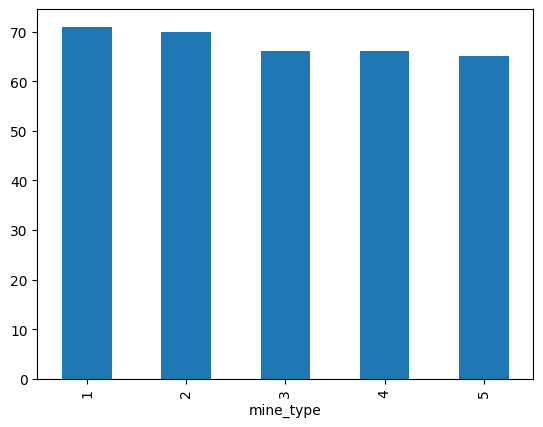

In [25]:
df['mine_type'].value_counts().sort_index().plot(kind='bar')

The dataset contains 338 observations with three features: voltage, height, and soil. The target variable is mine_type, which contains five classes. The classes are fairly balanced, with between 65 and 71 observations in each class. The features have values mostly ranging between 0 and 1.

In [26]:
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

In [29]:
print(X_train.shape)
print(X_test.shape)

(169, 3)
(169, 3)


In [30]:
from sklearn.neighbors import KNeighborsClassifier

In [31]:
from sklearn.metrics import accuracy_score

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    print(k, accuracy)

1 0.40236686390532544
2 0.4378698224852071
3 0.378698224852071
4 0.35502958579881655
5 0.3136094674556213
6 0.3254437869822485
7 0.3136094674556213
8 0.3136094674556213
9 0.34911242603550297
10 0.33727810650887574
11 0.35502958579881655
12 0.33727810650887574
13 0.34911242603550297
14 0.3136094674556213
15 0.33136094674556216
16 0.3431952662721893
17 0.3609467455621302
18 0.33727810650887574
19 0.33727810650887574
20 0.3431952662721893


In [32]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [33]:
y_pred = knn.predict(X_test)

In [34]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[25,  0,  6,  4,  1],
       [ 0, 32,  0,  3,  0],
       [12,  2,  9,  6,  4],
       [12,  5,  8,  8,  0],
       [15,  2, 10,  5,  0]])

In [35]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.4378698224852071

The model has an overall accuracy of approximately 43.8% It performs best on mine types 1 and 2, classifying 25 type 1 mines and 32 type 2 mines. Performance is much lower for types 3 & 4, with only 9 and 8 predictions. The model performs worst on type 5 with no correct predictions. The confusion table shows that type 5 is misclassified as type 1 or 3.

5.  I wouldnt recommend using this model as the only method for identifying a mine. The model is more accurate for some mine types like 1 and 2, but it can perform poorly for others. In particular, it did not correctly identify any type 5 mines in the test set. Since an incorrect prediction could be dangerous, the model should be used as an additional tool rather than as the final decision.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** f911f02
- **AI tool and model used:** ChatGPT

### *Prompts used

1.  Review my Phase 1 kNN solution and identify any errors or improvements I should make.
2. Review how I selected k and interpreted my confusion matrix. Are there any methodological or interpretation issues I should correct?

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Improve the selection of $k$ by evaluating multiple values systematically and avoiding using the final test set both to choose $k$ and to evaluate the selected model.
2. Present the confusion matrix with labeled rows and columns so it is easier to see the actual and predicted mine types.
3. Store and/or visualize the performance for the candidate $k$ values so the choice of $k$ is supported by clear evidence rather than only printed output.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Using the same test set to select $k$ and evaluate the final model can make the reported performance less reliable. I will use a separate validation approach to select $k$, then evaluate the final model on the test set. |
| 2 | Accept | Labeling the rows and columns of the confusion matrix will make it easier to identify the actual and predicted mine types and interpret the model's errors. |
| 3 | Accept | Storing and visualizing the accuracy for different values of $k$ will make it easier to compare the models and justify why a particular $k$ was selected. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [36]:
# Your Phase 2 solution to the problem goes here.


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('land_mines.csv')

df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [38]:
df.describe()

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [39]:
df['mine_type'].value_counts().sort_index()

,count
mine_type,
1,71
2,70
3,66
4,66
5,65


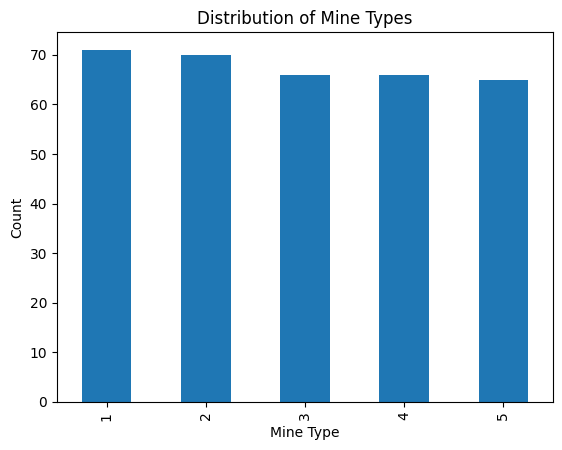

In [40]:
df['mine_type'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Mine Type')
plt.ylabel('Count')
plt.title('Distribution of Mine Types')
plt.show()

The dataset contains 338 observations with three features: voltage, height, and soil. The target variable is mine_type, which contains five classes (1–5). The classes are fairly balanced, with between 65 and 71 observations in each class. The features have values mostly ranging between 0 and 1.

In [41]:
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(169, 3)
(169, 3)


In [42]:
from sklearn.model_selection import cross_val_score

In [43]:
k_values = range(1, 21)
cv_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    cv_accuracies.append(scores.mean())

for k, accuracy in zip(k_values, cv_accuracies):
    print(k, accuracy)

1 0.3251336898395722
2 0.3903743315508021
3 0.3253119429590018
4 0.3306595365418895
5 0.37825311942959
6 0.384313725490196
7 0.37254901960784315
8 0.34884135472370764
9 0.37254901960784315
10 0.38467023172905523
11 0.36078431372549014
12 0.35561497326203206
13 0.34901960784313724
14 0.307843137254902
15 0.3253119429590018
16 0.3135472370766489
17 0.3370766488413547
18 0.3192513368983957
19 0.29590017825311943
20 0.325668449197861


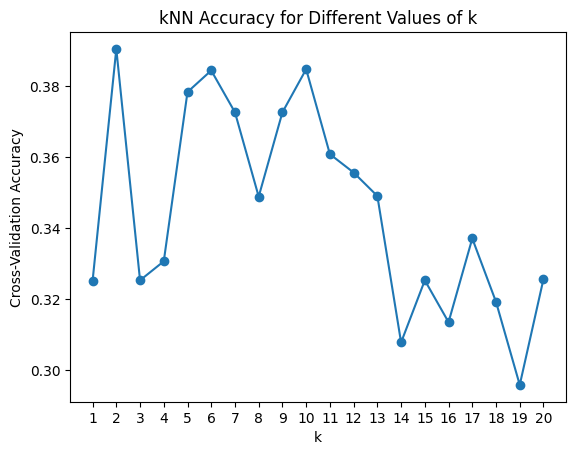

In [44]:
plt.plot(k_values, cv_accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Cross-Validation Accuracy')
plt.title('kNN Accuracy for Different Values of k')
plt.xticks(range(1, 21))
plt.show()

I tested values of $k$ from 1 to 20 using 5-fold cross-validation on the training data. This allowed me to select $k$ without using the final test set. The highest mean cross-validation accuracy was approximately 39.0% at $k$=2, so I selected $k$=2 for the final model.

In [45]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [46]:
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

Test accuracy: 0.4378698224852071


In [48]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual 1', 'Actual 2', 'Actual 3', 'Actual 4', 'Actual 5'],
    columns=['Predicted 1', 'Predicted 2', 'Predicted 3', 'Predicted 4', 'Predicted 5']
)

cm_df

,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,25,0,6,4,1
Actual 2,0,32,0,3,0
Actual 3,12,2,9,6,4
Actual 4,12,5,8,8,0
Actual 5,15,2,10,5,0


The final model has an accuracy of approximately 43.8%. It performs best on mine types 1 and 2, correctly classifying 25 type 1 mines and 32 type 2 mines. Performance is lower for types 3 and 4, with 9 and 8 correct predictions. The model performs worst on type 5, with no correct predictions. Type 5 is often incorrectly classified as type 1 or type 3.

I would not recommend using this model as the only method for identifying a mine. The model is more accurate for some mine types, such as types 1 and 2, but performs poorly for others. In particular, it did not correctly identify any type 5 mines in the test set. Since an incorrect prediction could be dangerous, the model should be used as an additional tool rather than as the final decision. Predictions should be verified using other information or methods before taking action.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvement I made with AI assistance was changing how I selected the value of k. In Phase 1, I tested different values of k directly on the test set and selected k=2 because it had the highest accuracy. AI pointed out that using the same test set to select k and evaluate the final model could affect the evaluation. In Phase 2, I used cross-validation on the training data instead. This still resulted in k=2 being selected, but it gave me a better method for choosing it without using the final test set.
Another improvement was making the confusion matrix easier to understand by adding labels for the actual and predicted mine types. AI also suggested storing or visualizing the accuracy for the different k values. I used the results from cross-validation to compare the different values systematically.
I verified the final solution by fitting the model with k=2 on the training data and then evaluating it on the test data. The final test accuracy was approximately 43.8%, and I checked the labeled confusion matrix to see where the model performed well or poorly. A remaining concern is that the model performs very differently across mine types, especially type 5, which had no correct predictions. Because of this, I would not rely on this model alone for real-world decisions.